# Week 7 – Model Optimisation & Trade-offs
## Building and Benchmarking a More Complex Model Against the Week 6 Baseline

**Student:** Shari Oliver

**Programme:** CariSurg MedTech Pathways — Healthcare AI

**Dataset:** `yaleemmlc_admissionprediction_triage.csv`

**Submission stage:** Interim Submission (Saturday 11:59 p.m. AST)

**Random seed:** 42

---

## Purpose of This Notebook

Week 6 delivered two interpretable baseline classifiers — logistic regression and a bounded decision tree — for predicting a patient's Emergency Severity Index (ESI) at triage. The ED Board has now asked a harder question: **what does a more sophisticated model buy us, and is it worth the extra complexity?**

This notebook is the technical engine room for that question. It exists to:

1. **Reuse** the exact Week 6 feature set, train/test split and preprocessing logic, so any performance difference we see is attributable to the model, not to a different data split.
2. **Implement a more complex model** — a Random Forest classifier — as the candidate for Phase 3.
3. **Benchmark it honestly** against the Week 6 baseline on the six required quantitative axes: accuracy, precision, recall, F1, training time and inference time.
4. **Assess interpretability** as a seventh, qualitative axis, since Martina Griffith (Clinical IT Lead) and Dr Reyes both need to be able to trust and explain individual predictions, not just look at a leaderboard.
5. Produce the **draft benchmark table** required for this week's interim KPI, ready to be dropped into `docs/` on GitHub.

## 1. Import Libraries and Configure the Environment

This section imports everything used in Week 6, plus what is new for Week 7: `time` for benchmarking training/inference speed, and `RandomForestClassifier` for the complex model. The random seed is fixed at 42, matching Week 6, so the train/test split reproduces exactly.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

print("Random Seed =", RANDOM_SEED)

Random Seed = 42


## 2. Create Output Folders

Generated figures and summary tables are saved into a Week 7 output folder, mirroring the Week 6 structure, so they can be copied straight into the GitHub `\notebooks` and `\docs` folders.

In [2]:
OUTPUT_DIR = Path("week7_outputs")

PLOT_DIR = OUTPUT_DIR / "plots"
DOC_DIR = OUTPUT_DIR / "docs"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
DOC_DIR.mkdir(parents=True, exist_ok=True)

print("Plots:", PLOT_DIR)
print("Documents:", DOC_DIR)

Plots: week7_outputs/plots
Documents: week7_outputs/docs


## 3. Load the Dataset

Same loading logic as Week 6. The raw dataset is **not committed to GitHub** because it contains programme-controlled data. The notebook checks the common local, Colab and Google Drive locations before loading.

In [3]:
DATASET_NAME = "yaleemmlc_admissionprediction_triage.csv"

possible_paths = [
    Path(DATASET_NAME),
    Path("/content") / DATASET_NAME,
    Path("/content/drive/MyDrive") / DATASET_NAME,
    Path("/content/drive/MyDrive/CariSurg") / DATASET_NAME,
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not locate '{DATASET_NAME}'. "
        "Please upload the dataset or update the file path."
    )

df = pd.read_csv(DATA_PATH, index_col=0)

print("Dataset loaded successfully!")
print(f"Dataset location: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Dataset loaded successfully!
Dataset location: yaleemmlc_admissionprediction_triage.csv
Rows: 54,077
Columns: 225


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Recreate the Week 6 Modelling Dataset

To make Week 7 a fair test of *model complexity* rather than a test of *different data*, the target definition and feature selection logic are copied verbatim from the Week 6 notebook. The predictor set is restricted to information realistically available at the moment of triage (vital signs, arrival information, chief complaint flags, and age), with any column that looks like a post-triage outcome (admission, disposition, length of stay, mortality, ICU, etc.) deliberately excluded to avoid data leakage.

**Note on fairness:** columns such as gender, ethnicity, race, language, religion, marital status, employment status and insurance are present in the raw dataset but were *not* used as predictors in Week 6, and are not used here either. This is a deliberate design choice — it keeps the model from learning to triage patients differently based on demographic or socioeconomic attributes. This is worth a sentence in the final cost-benefit memo as a stated design principle, not an oversight.

In [4]:
# -----------------------------
# Define target variable
# -----------------------------

TARGET = "esi"

# -----------------------------
# Candidate feature groups (identical logic to Week 6)
# -----------------------------

vital_features = [
    col for col in df.columns
    if any(term in col.lower() for term in
           ["hr","sbp","dbp","rr","o2","temp","glucose"])
]

arrival_features = [
    col for col in df.columns
    if "arrival" in col.lower()
]

chief_complaint_features = [
    col for col in df.columns
    if col.lower().startswith("cc_")
]

demographic_features = [
    col for col in ["age"]
    if col in df.columns
]

# Build final predictor list

selected_features = (
    demographic_features +
    vital_features +
    arrival_features +
    chief_complaint_features
)

selected_features = list(dict.fromkeys(selected_features))

print("Number of selected features:", len(selected_features))
print(selected_features[:20])

Number of selected features: 213
['age', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_blurredvision', 'cc_cardiacarrest', 'cc_diarrhea', 'cc_headache-recurrentorknowndxmigraines', 'cc_irregularheartbeat', 'cc_skinirritation', 'cc_sorethroat']


In [5]:
# -----------------------------
# Leakage check (identical logic to Week 6, kept as a guardrail)
# -----------------------------

leakage_keywords = [
    "admit",
    "admission",
    "disposition",
    "hospital",
    "los",
    "outcome",
    "death",
    "mortality",
    "icu"
]

possible_leakage = []

for col in df.columns:
    if any(word in col.lower() for word in leakage_keywords):
        possible_leakage.append(col)

print("Potential leakage variables (confirmed excluded from selected_features):")
possible_leakage

Potential leakage variables (confirmed excluded from selected_features):


['disposition', 'cc_breathingdifficulty', 'cc_lossofconsciousness']

In [6]:
model_df = df[selected_features + [TARGET]].copy()

# Remove rows with missing target values
model_df = model_df.dropna(subset=[TARGET])

# Ensure target is numeric
model_df[TARGET] = pd.to_numeric(
    model_df[TARGET],
    errors="coerce"
)

model_df = model_df.dropna(subset=[TARGET])

model_df[TARGET] = model_df[TARGET].astype(int)

X = model_df[selected_features]
y = model_df[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (54077, 213)
Target vector shape: (54077,)


## 5. Recreate the Week 6 Train/Test Split

Same 80/20 stratified split, same `random_state=42`. Because the feature selection above is byte-for-byte identical to Week 6 and the seed is unchanged, this reproduces the *exact same* train/test partition used for the baseline models — which is what the Week 7 brief specifically asks for ("Reuse your Week 6 train/test split").

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 43261
Testing observations: 10816


## 6. Preprocessing Pipelines

Identical to Week 6: numeric features are median-imputed, categorical features are most-frequent-imputed and one-hot encoded. Logistic regression additionally gets standardised numeric features. Random Forest, like the decision tree, does not need feature scaling, so it reuses the tree preprocessing pipeline.

In [8]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 209
Categorical Features: 4


In [9]:
numeric_pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer([
    ("numeric", numeric_pipeline_lr, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

preprocessor_tree = ColumnTransformer([
    ("numeric", numeric_pipeline_tree, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 7. Re-Establish the Week 6 Baselines, With Timing Instrumentation

Week 6 measured accuracy and classification metrics but did not measure **training time** or **inference time** — both of which are required axes for this week's benchmark, and both of which are exactly what Martina Griffith needs to reason about compute cost.

The models below are retrained here (same hyperparameters, same seed, same split as Week 6) purely so that timing can be captured under identical, controlled conditions alongside the new Random Forest model. This keeps the six-axis comparison fair — every model in the table is timed on the same machine, in the same run.

`fit_and_time()` and `predict_and_time()` are small helpers used for every model in this notebook (baseline and complex) so the timing methodology is consistent.

In [10]:
def fit_and_time(pipeline, X_train, y_train):
    """
    Fit a pipeline and return (fitted_pipeline, training_time_seconds).
    """
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    return pipeline, elapsed


def predict_and_time(pipeline, X_test, n_single_row_samples=200):
    """
    Predict on the full test set and return:
      - predictions
      - batch inference time per prediction (ms) = full-batch predict time / n_test
      - single-row inference time per prediction (ms) = mean of timing
        individual .predict() calls on a sample of rows

    Both numbers are reported because batch prediction (vectorised) is
    usually much faster per-row than the true one-patient-at-a-time
    latency a live ED triage system would actually experience.
    """
    start = time.perf_counter()
    predictions = pipeline.predict(X_test)
    batch_elapsed = time.perf_counter() - start
    batch_ms_per_prediction = (batch_elapsed / len(X_test)) * 1000

    sample_n = min(n_single_row_samples, len(X_test))
    sample_idx = np.random.RandomState(RANDOM_SEED).choice(
        len(X_test), size=sample_n, replace=False
    )

    single_row_times = []
    for i in sample_idx:
        row = X_test.iloc[[i]]
        start = time.perf_counter()
        pipeline.predict(row)
        single_row_times.append(time.perf_counter() - start)

    single_row_ms_per_prediction = np.mean(single_row_times) * 1000

    return predictions, batch_ms_per_prediction, single_row_ms_per_prediction

In [11]:
# -----------------------------
# Logistic Regression (Week 6 baseline #1)
# -----------------------------

logistic_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model",
     LogisticRegression(
         max_iter=2000,
         class_weight="balanced",
         random_state=RANDOM_SEED
     ))
])

logistic_model, logistic_train_time = fit_and_time(
    logistic_model, X_train, y_train
)

(
    logistic_predictions,
    logistic_batch_ms,
    logistic_single_ms
) = predict_and_time(logistic_model, X_test)

print("Logistic Regression trained successfully.")
print(f"Training time: {logistic_train_time:.3f} s")
print(f"Inference time (batch): {logistic_batch_ms:.4f} ms/prediction")
print(f"Inference time (single-row): {logistic_single_ms:.4f} ms/prediction")

Logistic Regression trained successfully.
Training time: 22.800 s
Inference time (batch): 0.0109 ms/prediction
Inference time (single-row): 7.4223 ms/prediction


In [12]:
# -----------------------------
# Decision Tree (Week 6 baseline #2)
# -----------------------------

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model",
     DecisionTreeClassifier(
         max_depth=5,
         class_weight="balanced",
         random_state=RANDOM_SEED
     ))
])

decision_tree_model, tree_train_time = fit_and_time(
    decision_tree_model, X_train, y_train
)

(
    tree_predictions,
    tree_batch_ms,
    tree_single_ms
) = predict_and_time(decision_tree_model, X_test)

print("Decision Tree trained successfully.")
print(f"Training time: {tree_train_time:.3f} s")
print(f"Inference time (batch): {tree_batch_ms:.4f} ms/prediction")
print(f"Inference time (single-row): {tree_single_ms:.4f} ms/prediction")

Decision Tree trained successfully.
Training time: 2.056 s
Inference time (batch): 0.0055 ms/prediction
Inference time (single-row): 6.9057 ms/prediction


## 8. Choosing the Complex Model: Random Forest

The brief allows a random forest, gradient boosting (XGBoost/LightGBM), or a small MLP. **Random Forest is selected** for three reasons directly tied to what the ED Board and Martina Griffith asked for:

1. **Compute cost.** A random forest trains on CPU in seconds-to-low-minutes on a dataset this size, with no GPU requirement, no extra dependency (`xgboost`/`lightgbm` would need to be installed and version-pinned in the deployment environment), and no learning-rate/epoch tuning burden the way an MLP would need. This is the cheapest "complex model" option to both train and to justify to IT Governance.
2. **A credible interpretability story.** Unlike an MLP, a random forest exposes `feature_importances_` natively and is a small step away (permutation importance, SHAP) from explaining individual predictions — which matters when Dr Reyes asks "why did the model say this patient was ESI 3?"
3. **Fit to the data.** Tabular clinical data with a mix of numeric vitals and one-hot encoded categorical flags is exactly the setting where tree ensembles tend to outperform linear models and are more stable than a small MLP trained on a modest number of rows.

Gradient boosting (XGBoost) was considered and is flagged as a candidate follow-up for the final memo if Random Forest's ESI Level 1 recall is not strong enough — but it adds a new dependency and more hyperparameters to tune, which is a real cost, not just a technical footnote.

**Hyperparameters used for this interim run:**
- `n_estimators=300` — enough trees to stabilise feature importances without excessive training time
- `max_depth=10` — bounded, to control training time and reduce overfitting risk (unbounded trees on a modest dataset can memorise noise)
- `class_weight="balanced"` — consistent with both Week 6 baselines, to address the ESI class imbalance
- `random_state=42` — consistent with Week 6, for reproducibility
- `n_jobs=-1` — uses all available CPU cores, which is itself a compute-cost consideration worth naming for Martina (more cores in production = faster training, but a real infrastructure cost)

These are a reasonable starting point for the interim submission, not a tuned final configuration — hyperparameter tuning (e.g. `RandomizedSearchCV`, as used in the COMP3220 assignment) is planned before the final memo if the initial numbers justify further investment.

In [13]:
# -----------------------------
# Random Forest (Week 7 complex model)
# -----------------------------

random_forest_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model",
     RandomForestClassifier(
         n_estimators=300,
         max_depth=10,
         class_weight="balanced",
         random_state=RANDOM_SEED,
         n_jobs=-1
     ))
])

random_forest_model, rf_train_time = fit_and_time(
    random_forest_model, X_train, y_train
)

(
    rf_predictions,
    rf_batch_ms,
    rf_single_ms
) = predict_and_time(random_forest_model, X_test)

print("Random Forest trained successfully.")
print(f"Training time: {rf_train_time:.3f} s")
print(f"Inference time (batch): {rf_batch_ms:.4f} ms/prediction")
print(f"Inference time (single-row): {rf_single_ms:.4f} ms/prediction")

Random Forest trained successfully.
Training time: 20.362 s
Inference time (batch): 0.0527 ms/prediction
Inference time (single-row): 100.1075 ms/prediction


## 9. Six-Axis Quantitative Benchmark

Every model is evaluated on the same six axes required by the brief: accuracy, precision, recall, F1 (macro and weighted, plus the ESI Level 1 class specifically since that is the primary clinical metric), training time and inference time. `evaluate_model()` is copied from Week 6 unchanged, so the numbers are directly comparable.

In [14]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Create summary and per-class evaluation tables
    for one classification model. (Unchanged from Week 6.)
    """
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        "ESI 1 Precision": report.get("1", {}).get("precision", np.nan),
        "ESI 1 Recall": report.get("1", {}).get("recall", np.nan),
        "ESI 1 F1": report.get("1", {}).get("f1-score", np.nan)
    }

    per_class = pd.DataFrame(report).T.reset_index()
    per_class = per_class.rename(
        columns={"index": "Class or Average"}
    )
    per_class.insert(0, "Model", model_name)

    return summary, per_class

In [15]:
model_results = {
    "Logistic Regression (Week 6)": {
        "predictions": logistic_predictions,
        "train_time": logistic_train_time,
        "batch_ms": logistic_batch_ms,
        "single_ms": logistic_single_ms,
    },
    "Decision Tree (Week 6)": {
        "predictions": tree_predictions,
        "train_time": tree_train_time,
        "batch_ms": tree_batch_ms,
        "single_ms": tree_single_ms,
    },
    "Random Forest (Week 7)": {
        "predictions": rf_predictions,
        "train_time": rf_train_time,
        "batch_ms": rf_batch_ms,
        "single_ms": rf_single_ms,
    },
}

summary_rows = []
per_class_tables = []

for model_name, result in model_results.items():
    summary, per_class = evaluate_model(
        model_name,
        y_test,
        result["predictions"]
    )
    summary["Training Time (s)"] = result["train_time"]
    summary["Inference Time — Batch (ms/prediction)"] = result["batch_ms"]
    summary["Inference Time — Single Row (ms/prediction)"] = result["single_ms"]

    summary_rows.append(summary)
    per_class_tables.append(per_class)

six_axis_benchmark = pd.DataFrame(summary_rows).round(4)
per_class_metrics = pd.concat(per_class_tables, ignore_index=True).round(3)

display(six_axis_benchmark)

,Model,Accuracy,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,ESI 1 F1,Training Time (s),Inference Time — Batch (ms/prediction),Inference Time — Single Row (ms/prediction)
0,Logistic Regression (Week 6),0.5800,0.4242,0.6120,0.0192,0.7333,0.0374,22.8000,0.0109,7.4223
1,Decision Tree (Week 6),0.2517,0.1690,0.2875,0.0124,0.5333,0.0242,2.0556,0.0055,6.9057
2,Random Forest (Week 7),0.4772,0.3996,0.4729,0.3333,0.3333,0.3333,20.3617,0.0527,100.1075


In [16]:
display(per_class_metrics)

,Model,Class or Average,precision,recall,f1-score,support
0,Logistic Regression (Week 6),1,0.019,0.733,0.037,15.000
1,Logistic Regression (Week 6),2,0.668,0.617,0.642,3515.000
2,Logistic Regression (Week 6),3,0.761,0.537,0.630,5302.000
3,Logistic Regression (Week 6),4,0.502,0.612,0.552,1746.000
4,Logistic Regression (Week 6),5,0.158,0.748,0.261,238.000
5,Logistic Regression (Week 6),accuracy,0.580,0.580,0.580,0.580
6,Logistic Regression (Week 6),macro avg,0.422,0.649,0.424,10816.000
7,Logistic Regression (Week 6),weighted avg,0.675,0.580,0.612,10816.000
8,Decision Tree (Week 6),1,0.012,0.533,0.024,15.000
9,Decision Tree (Week 6),2,0.502,0.480,0.491,3515.000


In [17]:
six_axis_benchmark.to_csv(
    DOC_DIR / "SOliver_Week7_Draft_Benchmark_Table.csv",
    index=False
)

per_class_metrics.to_csv(
    DOC_DIR / "SOliver_Week7_Per_Class_Metrics.csv",
    index=False
)

print("Draft benchmark table and per-class metrics saved successfully.")

Draft benchmark table and per-class metrics saved successfully.


### Interpretation

This table is the **draft benchmark table** required for the interim KPI. It compares both Week 6 baselines against the Week 7 Random Forest on accuracy, macro F1, weighted F1, ESI Level 1 precision/recall/F1, training time and inference time (both batch and realistic single-patient latency).

At this stage, do not over-interpret small differences — this is one train/test split, hyperparameters are not yet tuned, and the final memo will need to discuss variance/robustness before making a firm recommendation. What this table *is* useful for right now is spotting whether the Random Forest's ESI Level 1 recall is meaningfully better than the best Week 6 baseline, and whether that improvement is large enough to be worth the training-time and inference-time cost it adds.

## 10. Interpretability — the Seventh, Qualitative Axis

The brief requires a qualitative interpretability axis: **can you explain a single prediction to Dr Reyes in under a minute?**

- **Logistic Regression:** Yes, in principle — each feature has a signed coefficient — but with dozens of one-hot encoded chief-complaint columns, "explaining a prediction" means walking through many small contributions at once. Moderately fast to explain in aggregate, slower for one specific patient.
- **Decision Tree (`max_depth=5`):** Yes, easily. A single prediction is one path down the tree — at most 5 yes/no questions. This is the most defensible model in a room with a clinician who wants to see the exact reasoning.
- **Random Forest (300 trees):** Not directly. There is no single path to point to — a prediction is a vote across 300 trees. What *is* available is a **global** feature importance ranking (which features matter most across all patients) and, with more work for the final submission, **local** explanation tools (permutation importance on a single row, or SHAP) that approximate a decision-tree-style explanation for one patient. For the interim submission, global feature importance is computed below as a first pass.

This is the central trade-off the cost-benefit memo will have to make a call on: the decision tree can be explained on a whiteboard in front of Dr Reyes; the random forest cannot, in the same direct way, even if its aggregate accuracy is better.

In [18]:
# Recover feature names after one-hot encoding, for the Random Forest

rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_importances = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": random_forest_model.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

top_features = rf_importances.head(15)

display(top_features)

,Feature,Importance
215,categorical__arrivalmode_ambulance,0.091403
181,numeric__cc_strokealert,0.086413
0,numeric__age,0.072965
2,numeric__triage_vital_sbp,0.066470
3,numeric__triage_vital_dbp,0.053576
4,numeric__triage_vital_rr,0.050843
18,numeric__cc_abdominalpain,0.048565
1,numeric__triage_vital_hr,0.043233
6,numeric__triage_vital_o2_device,0.042959
8,numeric__triage_glucose,0.036388


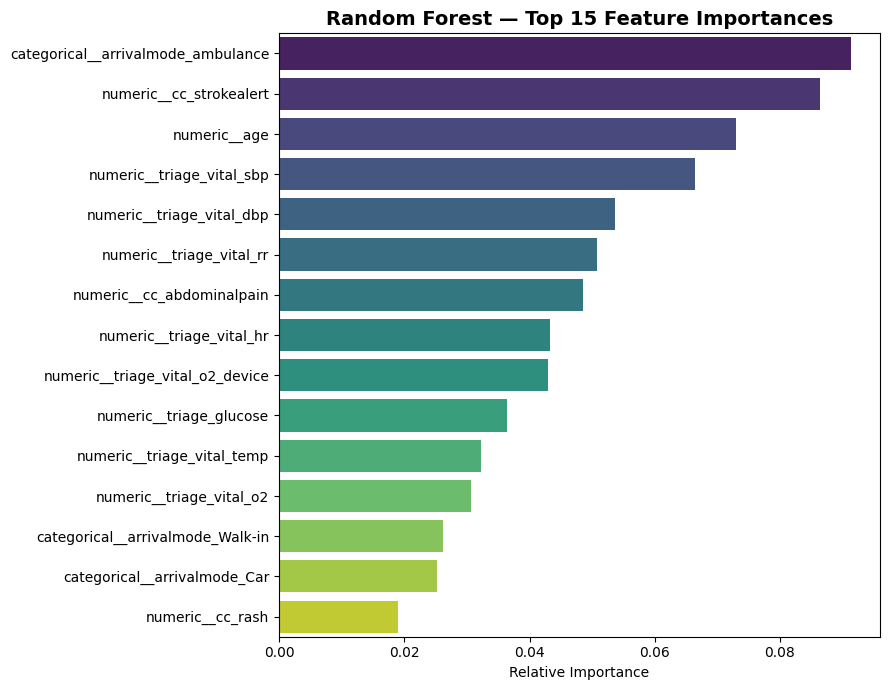

In [26]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_features,
    y="Feature",
    x="Importance",
    palette="viridis"
)

plt.title("Random Forest — Top 15 Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "SOliver_Week7_RandomForest_Feature_Importance.png",
    dpi=300
)

plt.show()

### Interpretation

The top features give a global sense of what the Random Forest is relying on — for example, whether vital signs dominate (clinically reassuring) or whether the model is leaning heavily on a handful of chief-complaint flags (which may be a sign of a narrower, less generalisable model). This plot should be sense-checked against clinical intuition before the final memo: if the top features look clinically implausible, that is a red flag worth raising with Dr Reyes, not a result to quietly accept.

**Planned for final submission:** SHAP values for a small set of individual test patients (including at least one true ESI Level 1 case), so the memo can show — not just claim — what "explaining a prediction" would actually look like for the Random Forest.

## 11. Confusion Matrix — Random Forest

Same confusion matrix approach as Week 6, applied to the Random Forest. Rows are actual ESI level, columns are predicted ESI level. As in Week 6, the cell of greatest concern is any true ESI Level 1 patient predicted as a less urgent level.

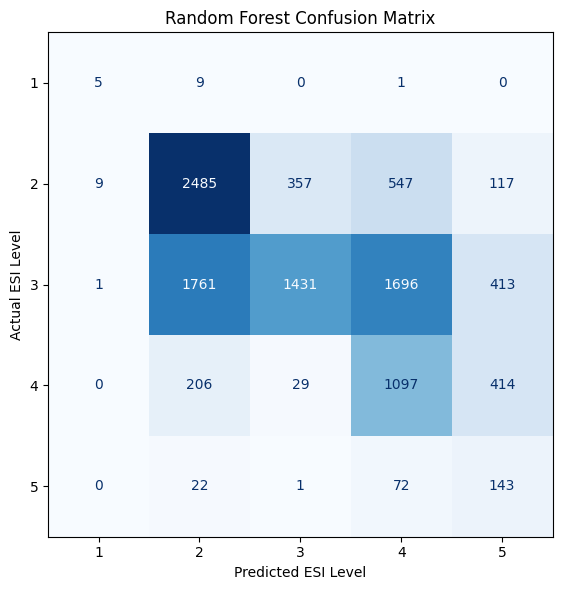

Saved: week7_outputs/plots/SOliver_Week7_RandomForest_Confusion_Matrix.png


In [20]:
labels = sorted(y_test.unique())

def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted ESI Level")
    ax.set_ylabel("Actual ESI Level")

    plt.tight_layout()

    output_path = PLOT_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

    return cm


rf_cm = save_confusion_matrix(
    y_test,
    rf_predictions,
    "Random Forest Confusion Matrix",
    "SOliver_Week7_RandomForest_Confusion_Matrix.png"
)

## 12. ESI Level 1 Failure-Mode Analysis — Random Forest

Same methodology as Week 6: for every true ESI Level 1 patient, check whether the model correctly identified them, and if not, where they were misclassified to. This stays the primary safety lens for judging whether added complexity is actually worth it.

In [21]:
def esi1_failure_summary(y_true, y_pred, model_name):
    results = pd.DataFrame({
        "Actual ESI": y_true.to_numpy(),
        "Predicted ESI": y_pred
    })

    actual_esi1 = results[results["Actual ESI"] == 1].copy()
    missed_esi1 = actual_esi1[actual_esi1["Predicted ESI"] != 1]

    summary = pd.DataFrame({
        "Model": [model_name],
        "Actual ESI 1 Patients": [len(actual_esi1)],
        "Correctly Identified": [(actual_esi1["Predicted ESI"] == 1).sum()],
        "Missed ESI 1 Patients": [len(missed_esi1)],
        "ESI 1 Recall": [
            (actual_esi1["Predicted ESI"] == 1).mean()
            if len(actual_esi1) > 0
            else np.nan
        ]
    })

    missed_breakdown = (
        missed_esi1["Predicted ESI"]
        .value_counts()
        .sort_index()
        .rename_axis("Incorrect Predicted ESI Level")
        .reset_index(name="Number of Missed ESI 1 Patients")
    )

    return summary, missed_breakdown


logistic_failure_summary, logistic_missed_levels = esi1_failure_summary(
    y_test, logistic_predictions, "Logistic Regression (Week 6)"
)

tree_failure_summary, tree_missed_levels = esi1_failure_summary(
    y_test, tree_predictions, "Decision Tree (Week 6)"
)

rf_failure_summary, rf_missed_levels = esi1_failure_summary(
    y_test, rf_predictions, "Random Forest (Week 7)"
)

failure_summary = pd.concat(
    [logistic_failure_summary, tree_failure_summary, rf_failure_summary],
    ignore_index=True
).round(3)

display(failure_summary)

,Model,Actual ESI 1 Patients,Correctly Identified,Missed ESI 1 Patients,ESI 1 Recall
0,Logistic Regression (Week 6),15,11,4,0.733
1,Decision Tree (Week 6),15,8,7,0.533
2,Random Forest (Week 7),15,5,10,0.333


In [22]:
print("Random Forest: where missed ESI Level 1 patients were placed")
display(rf_missed_levels)

failure_summary.to_csv(
    DOC_DIR / "SOliver_Week7_ESI1_Failure_Summary.csv",
    index=False
)

print("Failure-mode summary saved.")

Random Forest: where missed ESI Level 1 patients were placed


,Incorrect Predicted ESI Level,Number of Missed ESI 1 Patients
0,2,9
1,4,1


Failure-mode summary saved.


## 13. Side-by-Side Comparison Chart

A single chart summarising accuracy, macro F1, weighted F1 and ESI Level 1 recall across all three models, for a quick visual gut-check before the numbers go into the memo.

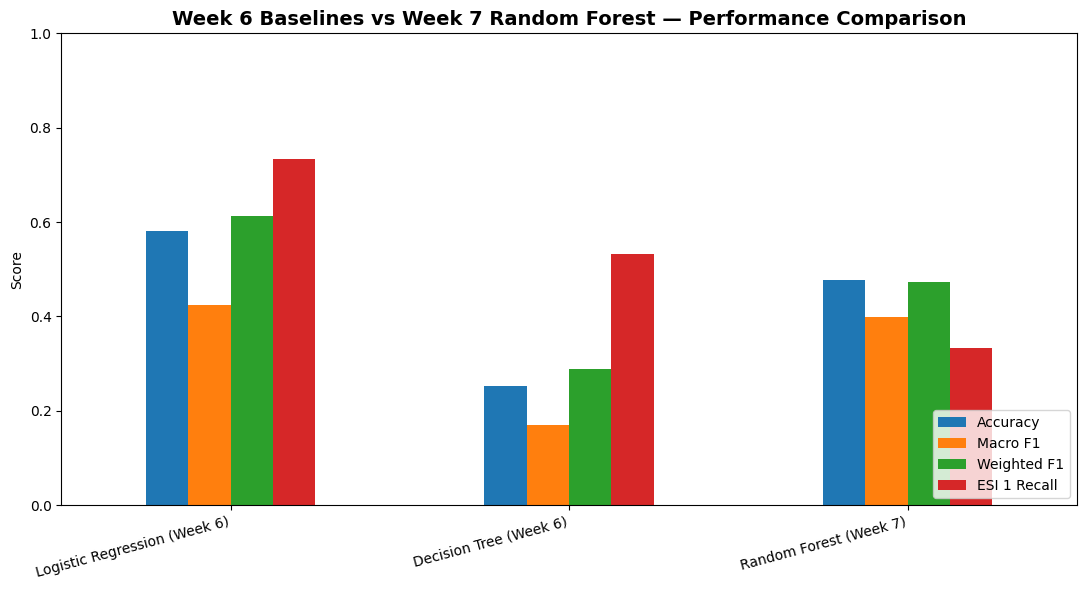

In [28]:
comparison_plot_data = (
    six_axis_benchmark
    .set_index("Model")[["Accuracy", "Macro F1", "Weighted F1", "ESI 1 Recall"]]
)

ax = comparison_plot_data.plot(kind="bar", figsize=(11, 6))

ax.set_title("Week 6 Baselines vs Week 7 Random Forest — Performance Comparison", fontsize = 14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)

plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    PLOT_DIR / "SOliver_Week7_Model_Comparison.png",
    dpi=300
)

plt.show()

## 14. Preliminary Compute-Cost Reflection (for Martina Griffith)

This is a first pass at the compute-cost angle Martina raised — not the final cost-benefit analysis, which belongs in the memo. The idea is to turn the raw timing numbers into something closer to an operational question: **what does this model actually cost to run in an ED?**

Two scenarios are sketched below using the timing figures measured earlier in this notebook:

1. **Daily inference cost** — using the *single-row* inference time (the realistic one-patient-at-a-time latency), scaled to an assumed daily ED patient volume.
2. **Retraining cost** — using training time, scaled to an assumed retraining cadence (e.g. monthly, as new triage data accumulates).

The `assumed_daily_patients` and `retrains_per_year` values below are illustrative placeholders — replace them with real ED volume figures before this goes into the memo.

In [24]:
assumed_daily_patients = 150   # placeholder — replace with real ED daily volume
retrains_per_year = 12         # placeholder — e.g. monthly retraining

cost_reflection_rows = []

for _, row in six_axis_benchmark.iterrows():
    daily_inference_seconds = (
        row["Inference Time — Single Row (ms/prediction)"] / 1000
        * assumed_daily_patients
    )
    annual_retraining_seconds = row["Training Time (s)"] * retrains_per_year

    cost_reflection_rows.append({
        "Model": row["Model"],
        "Assumed Daily Patients": assumed_daily_patients,
        "Est. Daily Inference Time (s)": round(daily_inference_seconds, 3),
        "Assumed Retrains / Year": retrains_per_year,
        "Est. Annual Retraining Time (s)": round(annual_retraining_seconds, 3),
    })

compute_cost_reflection = pd.DataFrame(cost_reflection_rows)

compute_cost_reflection.to_csv(
    DOC_DIR / "SOliver_Week7_Compute_Cost_Reflection.csv",
    index=False
)

display(compute_cost_reflection)

,Model,Assumed Daily Patients,Est. Daily Inference Time (s),Assumed Retrains / Year,Est. Annual Retraining Time (s)
0,Logistic Regression (Week 6),150,1.113,12,273.600
1,Decision Tree (Week 6),150,1.036,12,24.667
2,Random Forest (Week 7),150,15.016,12,244.340


### Interpretation

At ED patient volumes, even the slowest model here is unlikely to be a *latency* problem — triage decisions happen on a human timescale of minutes, not milliseconds. The more meaningful cost driver is likely to be **infrastructure and maintenance**: does the Random Forest need a heavier deployment environment, more memory to hold 300 trees, and more engineering time to build the SHAP-based explanation tooling Section 10 flagged as necessary? That is a better framing for the memo than raw milliseconds, and is worth discussing directly with Martina before the final write-up.

## 15. Interim Summary and Next Steps

**What this notebook has delivered for the interim submission:**

- A trained Random Forest classifier (the Week 7 complex model), built on the exact Week 6 feature set and train/test split.
- Timing-instrumented retraining of both Week 6 baselines, so all three models are compared on equal footing.
- A six-axis quantitative benchmark table (`SOliver_Week7_Draft_Benchmark_Table.csv`), saved to `week7_outputs/docs/`.
- A first-pass interpretability assessment, including global feature importances for the Random Forest.
- A confusion matrix and ESI Level 1 failure-mode breakdown for the new model.
- A placeholder compute-cost reflection to seed the conversation with Martina Griffith.

In [25]:
print("Generated plot files:")
for file in sorted(PLOT_DIR.glob("*")):
    print("-", file.name)

print("\nGenerated document files:")
for file in sorted(DOC_DIR.glob("*")):
    print("-", file.name)

Generated plot files:
- SOliver_Week7_Model_Comparison.png
- SOliver_Week7_RandomForest_Confusion_Matrix.png
- SOliver_Week7_RandomForest_Feature_Importance.png

Generated document files:
- SOliver_Week7_Compute_Cost_Reflection.csv
- SOliver_Week7_Draft_Benchmark_Table.csv
- SOliver_Week7_ESI1_Failure_Summary.csv
- SOliver_Week7_Per_Class_Metrics.csv
